# Backpropagation

In this notebook, we explore how to code backpropagation (backward autodiff) in Python. We follow the video by [Andrej Karpathy](https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ).

## Autodifferentiation

Autodifferentiation is used to find the elements of a Jacobian matrix $J$ of a function $f: \mathbb{R}^n \to \mathbb{R}^m$, with $n$ inputs and $m$ outputs:
$$
J_{ij} = \frac{\partial f_i}{\partial x_j}.
$$

The way autodiff works is by building a computation graph, which shows how each variable is linked to the others through given operations. Each operation is then broken into "atomic" operations for which the derivative is known (for example, addition, multiplication, and elementary functions). We then apply the chain rule.

For example, if we have $f = e^{xy} + z$, we might break this down into $a = xy$, and then $f = e^a + z$. To compute $\frac{\partial f}{\partial x}$:

$$
\frac{\partial f}{\partial x} 
= \frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial x} 
+ \frac{\partial f}{\partial z} \cdot \frac{\partial z}{\partial x}
= \frac{\partial f}{\partial a} \cdot \frac{\partial a}{\partial x}
= y e^{xy}.
$$

Each intermediate variable is represented as a node in the graph, and different nodes are connected through operations (edges).

There are two ways to compute the Jacobian:

1. Start from the input variables and traverse the graph forward until you reach the outputs (forward differentiation).
2. Start from the output and traverse the graph backward (backward differentiation).

The rule of thumb is the following:

- Use forward mode when the number of input variables is greater than the number of output variables ($n > m$).
- Use backward mode when the number of output variables is greater than the number of input variables ($m > n$).

This can be explained as follows. Assume that there is a maximum cost of $C$ to traverse the graph starting from a given node. If we start from the inputs, then the total cost of forward mode is $\mathcal{O}(nC)$, and of backward mode is $\mathcal{O}(mC)$.

## Coding

### Value object

The goal is to construct a class called `Value`, which represents numerical values while also tracking how they are computed from other variables. This allows us to:
- perform operations such as addition and multiplication between `Value` objects  
- support automatic differentiation (backpropagation)

Each `Value` object has the following attributes:

- **data**: the numerical value it stores  
- **_prev**: a set of the previous nodes (called children) in the computation graph (i.e. the operands used to compute this value)  
- **_op**: the operation that produced this value (e.g. `+`, `*`, etc.)  
- **label**: a string used to identify or label the node  
- **grad**: the gradient of the output with respect to the variable in the current node
- **_backward**: a function called to propagate the gradient backwards to the children

---

### On the meaning of `_prev` / “children”

At first, it may seem counterintuitive to refer to `_prev` as “children,” since in a forward computation such as:

\[
z = x + y
\]

one might naturally think of `x` and `y` as inputs and `z` as their output, meaning that `x` and `y` are the “parents” of `z`.

However, in this implementation we intentionally adopt the opposite viewpoint.

The computation graph is traversed in the **reverse direction**, starting from the output node (typically the loss function in deep learning) and moving backward toward the input variables. From this perspective, each node connects to the values it depends on, so the variables used to construct a given node are treated as its “children” in the traversal sense.

For example, if:

\[
z = x + y
\]

then `x` and `y` are considered the children of `z` because we represent the graph with directed edges:


---

### Why this direction is used

This design choice is motivated by deep learning applications. In neural networks, we typically compute a single scalar loss function at the output. To efficiently compute gradients of this loss with respect to all parameters, we use **reverse-mode automatic differentiation (backpropagation)**.

Reverse-mode AD is efficient because it:
- starts from the output (loss), and  
- propagates gradients backward through the computation graph to the inputs  

From this backward perspective, the nodes that were originally used to construct a value naturally become its “children” in the traversal sense.

---

### `_backward` function

The core of the implementation is the `_backward` function, which updates the `node.grad` attribute for each node in the computational graph.

Its behavior depends on the operation that produced the node. Below we illustrate the cases of **addition** and **multiplication**, but the same principle extends to any differentiable operation.


For each node $x_j$, we want to compute:
$$
x_j.\text{grad} \equiv \frac{\partial L}{\partial x_j}
$$
where $L$ is the final output (typically the loss). By definition, `x_j.grad` stores this quantity.


We begin from the output node:
$$
x_1 \equiv L
$$
and initialize:
$$
\frac{\partial L}{\partial L} = 1
$$

We then traverse the graph **backward**, propagating gradients from each node to its children. Calling `L._backward()` triggers this process, and `_backward` is applied recursively (or iteratively) to all nodes encountered during the traversal.


Consider a generic node $x_j$ computed from $x_{j-1}$ and $x_{j-2}$.

#### 1) Addition

$$
x_j = x_{j-1} + x_{j-2}
$$

$$
x_{j-1}.\text{grad} \mathrel{+\!=}
\frac{\partial L}{\partial x_j}
\cdot
\frac{\partial x_j}{\partial x_{j-1}}

 \frac{\partial L}{\partial x_j} \cdot 1

x_j.\text{grad}
$$

So, the gradient is passed unchanged to each operand.


#### 2) Multiplication

$$
x_j = x_{j-1} \cdot x_{j-2}
$$

$$
x_{j-1}.\text{grad} \mathrel{+\!=}
\frac{\partial L}{\partial x_j}
\cdot
\frac{\partial x_j}{\partial x_{j-1}}

\frac{\partial L}{\partial x_j} \cdot x_{j-2}

x_j.\text{grad} \cdot x_{j-2}
$$

Here, the gradient is scaled by the other operand.


### Why we use `+=` instead of `=`

In both cases, we **accumulate** gradients using `+=` rather than assigning with `=`.

This is essential because a node may influence the output through **multiple paths** in the graph. Each path contributes a term to the total derivative, and all contributions must be summed.

This is a direct consequence of the **chain rule**.


### Example (multiple paths)

If a variable $x_3$ affects the loss through two intermediate nodes:
$$
L = L(x_1(x_3), x_2(x_3))
$$

then:
$$
\frac{\partial L}{\partial x_3} = 

\frac{\partial L}{\partial x_1} \cdot \frac{\partial x_1}{\partial x_3}
+
\frac{\partial L}{\partial x_2} \cdot \frac{\partial x_2}{\partial x_3}
$$

So during backpropagation, each contribution is computed separately and **accumulated** into `x_3.grad`.

This is why gradient updates must be cumulative: every path through the graph contributes to the final result.


### Topological order


We have defined the _backward function, we now need to define an order in which to call the _backward function for each node. 

This can be done using topological sorting. This is a way to order the nodes of a directed graph in such a way that if $u$ is connected to $v$ then in the sorted list $u$ comes before $v$. This order is not unique and such it exists if and only if there are no directed cycles.
We can define a generic algorithm to find the topological sort using a depth first search (DFS) algorithm, which we then adapt to our Value class.

In [1]:
def top_sort(graph):

    """Find the topological sort of a graph (with no cycles) given its dictionary"""

    topo_sort = []
    visited = set()


    nodes = set(graph.keys())

    for neighbors in graph.values():
        nodes.update(neighbors)

    
    def DFS(node):
        if node in visited:
            return
        
        visited.add(node)
        for neighbor in graph.get(node, []):
            DFS(neighbor)

        topo_sort.append(node) #append the node to topological sort only after all of its children are processed


    for node in nodes:
        if node not in visited:
            DFS(node)

    return topo_sort


In [2]:
# Example of usage

graph = {"a": ["c"], "b": ["c"], "c": ["e", "d"], "e": ["f"], "d": ["g"]}

top_sort(graph)

['f', 'e', 'g', 'd', 'c', 'b', 'a']

In [3]:
import math

class Value:

    def __init__(self, data, _children = (), _op = "", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self.label = label
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value({self.data:.2f}, {self.label})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward(): # chain rule for addition out = self+other, df(out)/dself = self.grad =  1*
            self.grad += 1.0*out.grad 
            other.grad += 1.0*out.grad

        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        return self*-1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return Value((other.data if isinstance(other, Value) else other) - self.data)

    def __mul__(self, other):
        
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self*other
    

    def __pow__(self, other):
        # raise variable to a constant
        assert isinstance(other, (int,float))
        out = Value(self.data**other,  (self, ), f"**{other}")

        def _backward():
            self.grad += other*(self.data**(other-1))*out.grad

        out._backward = _backward
        return out
        

    def __truediv__(self, other):
        return self*other**-1
    
    def exp(self):
        out =  Value(math.exp(self.data), (self, ), "exp")
        def _backward():
            self.grad += out.data*out.grad

        out._backward = _backward

        return out
    
    def relu(self):
        out = Value(max(self.data, 0), (self, ), "ReLU")

        def _backward():
            self.grad += int(self.data > 0)*out.grad

        out._backward = _backward
        return out
    
    def sigmoid(self):
        out = Value(1/(1+math.exp(-self.data)), (self, ), "ReLU")

        def _backward():
            self.grad += (math.exp(-self.data)/(1+math.exp(-self.data))**2)*out.grad

        out._backward = _backward
        return out

    def backward(self):
        
        topo_sort = []
        visited = set()


        def build_topo(node):

            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build_topo(child)
                topo_sort.append(node)

        
        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo_sort):
            node._backward()

## Computational graph

We use `Digraph` from Graphviz to visualize the computational graph.

To make this work, Graphviz must be installed on your system (so that the `dot` executable is available) and the Python `graphviz` package must also be installed. In practice, this means:
- installing Graphviz on your machine, and  
- ensuring its `bin` directory is added to your system PATH so Python can access `dot`.

---

### Basic usage

We first create a directed graph object:

```python
dot = Digraph()

dot.node("A")          # creates a node labeled "A"
dot.node("B")          # creates a node labeled "B"

dot.edge("A", "B")     # creates a directed edge A → B

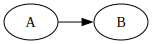

In [4]:
from graphviz import Digraph

dot = Digraph(graph_attr={"rankdir":"LR"})

dot.node("A")          # creates a node labeled "A"
dot.node("B")          # creates a node labeled "B"

dot.edge("A", "B")     # creates a directed edge A → B

dot

In [5]:
def trace(root):

    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

        for child in v._prev:
            edges.add((child, v))
            build(child)

    build(root)
    return nodes, edges


def draw_graph(root):

    dot = Digraph(format="svg", graph_attr={"rankdir":"LR"})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name= uid, label = f"{n.label} | data {n.data:.4f} | grad {n.grad:.4f}", shape = "record")

        if n._op:
            dot.node(name=uid + n._op, label = n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)

    return dot


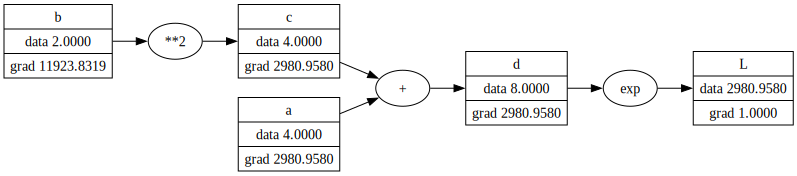

In [6]:
a = Value(4, label = "a")
b = Value(2, label = "b")
c = b**2
c.label = "c"
d = a + c
d.label = "d"
L = d.exp()
L.label = "L"

L.backward()

draw_graph(L)

This example agrees with the manual computation of the derivatives.

We define:
$$
L = e^{d}, \quad
d = a + c, \quad
c = b^2
$$

Applying the chain rule, we obtain:
$$
\frac{\partial L}{\partial L} = 1
$$

$$
\frac{\partial L}{\partial d} = e^d = e^{8} \approx 2981
$$

$$
\frac{\partial L}{\partial a} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial a}
= e^d \cdot 1
= e^d \approx 2981
$$

$$
\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial c}
= e^d \cdot 1
= e^d \approx 2981
$$

$$
\frac{\partial L}{\partial b} = \frac{\partial L}{\partial c} \cdot \frac{\partial c}{\partial b}
= e^d \cdot 2b
= 2b\,e^d
= 2 \cdot 2 \cdot e^8 \approx 11924
$$

# Gradient descent on a MLP

We now implement a simple 2-layer perceptron and use gradient descent to optimise its parameters.

In [ ]:
import numpy as np

class Neuron:

    def __init__(self, nin):
        # nin is the number of features
        self.w = [Value(np.random.normal()) for _ in range(nin)]
        self.b = Value(np.random.normal())


    def __call__(self, x):

        # w^Tx + b

        out = sum(wi * xi for wi, xi in zip(self.w, x)) + self.b  # Do not use np.dot here: it breaks the Value-based autograd graph

        return out
    
    def parameters(self):
        return self.w + [self.b]
    

class Layer:

    def __init__(self, nin, nout, activation):

        # nout -> number of neurons in the layer

        self.neurons = [Neuron(nin) for _ in range(nout)]
        self.activation = activation

    def __call__(self, x):

        neurons = [n(x) for n in self.neurons]

        out = [self.activation(o) for o in neurons]

        return out if len(out)>1 else out[0]
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    

class MLP:

    def __init__(self, nin, nouts, acts):
        
        s = [nin] + nouts

        self.layers = [Layer(s[i], s[i+1], acts[i]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)

        return x    
    
    def parameters(self):

        return [p for layer in self.layers for p in layer.parameters()]


### Example

We construct a dataset consisting of input vectors in $\mathbb{R}^2$. 
Each input $[x_1, x_2]$ is mapped to a target value $y \in (0,1)$ defined by

$$
[x_1, x_2] \mapsto y =
\begin{cases}
\displaystyle \frac{1}{1 + e^{-x_2}} & \text{if } x_1^2 + x_2^2 < 9, \\[8pt]
\displaystyle \frac{1}{1 + e^{-x_1}} & \text{otherwise.}
\end{cases}
$$

The goal of the MLP is therefore to learn both the nonlinear decision boundary 
(the circle $x_1^2 + x_2^2 = 9$) and the corresponding functional behavior on each region.

In [ ]:
class ReLU:
    def __call__(self, x):
        return x.relu()

class Sigmoid:
    def __call__(self, x):
        return x.sigmoid()

xs = [
    [2.0, 4.0],
    [7.0, 8.0],
    [10.0, 9.0],
    [1.0, 10.0],
    [3.5, 1.2],
    [6.8, 9.1],
    [0.7, 4.4],
    [8.3, 2.6],
    [-2.0, -4.0],  
    [-7.0, 8.0],   
    [10.0, -9.0],  
    [-1.0, -10.0], 
    [-3.5, 1.2],   
    [6.8, -9.1],   
    [-0.7, -4.4],  
    [-8.3, 2.6],   
    [5.9, -7.7],   
    [-9.4, -3.3],  
]


f = lambda x1, x2: 1/(1+np.exp(-x2)) if x1**2 + x2**2 < 9 else 1/(1+np.exp(-x1))



ytar = [f(x1,x2) for x1,x2 in xs]

# Implement an MLP with 3 layers with ReLU,ReLU,Sigmoid activation fucntions. The first layer has 4 neurons, the second 4 and the last 1

n = MLP(2,[4,4,1], [ReLU(), ReLU(), Sigmoid()])


for k in range(100):

    # forward pass

    ypred = [n(x) for x in xs]

    loss = sum((ypred_i - ytar_i)**2 for ypred_i, ytar_i in zip(ypred, ytar))*1/len(ypred)
    # backward pass
    for p in n.parameters():
        p.grad = 0 #reset the grad to zero
    loss.backward()  #compute the grad

    for p in n.parameters():
        p.data-= 0.1*p.grad  #gradient descent

    if k%5==0:
        print(f"Iteration {k}:", loss.data) #loss should go down at each iteration

Iteration 0: 0.27720294950535374
Iteration 5: 0.19368898911655072
Iteration 10: 0.1765001597931349
Iteration 15: 0.15905944150449694
Iteration 20: 0.13880277165169716
Iteration 25: 0.11505671876906298
Iteration 30: 0.09206266216467841
Iteration 35: 0.07636726275356656
Iteration 40: 0.06825830714119499
Iteration 45: 0.06366689443792564
Iteration 50: 0.06067055247491747
Iteration 55: 0.05847578108377354
Iteration 60: 0.056704728664125875
Iteration 65: 0.05520633394403232
Iteration 70: 0.05389743927397504
Iteration 75: 0.05273229865265017
Iteration 80: 0.051686332252964866
Iteration 85: 0.05074575573117174
Iteration 90: 0.04990177101784096
Iteration 95: 0.04914740728910409
